In [1]:
%%capture
!pip install indiafactorlibrary

In [2]:
# Notebook: 04_momentum_deep_dive
# Series:   pyIndiaFactorInvesting
# Data:     Invespar Indian Factor Library (Oct 2004 – Feb 2026) + Nifty sample (Jan 2015 – Dec 2020)
# Run in:   Colab / Binder / local
# Author:   Rajan Raju

# Momentum Deep Dive

Momentum — the tendency of recent winners to continue outperforming recent losers — is one of the most replicated anomalies in asset pricing.  In the Indian equity market the WML (Winners Minus Losers) factor captures this premium using a 12-1 month ranking window and a 2×3 size-momentum sort, reconstituted monthly.

This notebook goes beneath the summary statistics and examines four dimensions that are essential for any practitioner: the factor's return profile and crash anatomy, its interactions with value and the market, how academic long-short WML maps onto real-world long-only momentum indices, and the implementation frictions that determine whether the premium can actually be harvested.

**What you will leave with**
- WML summary statistics, cumulative return path, and five key market episodes
- Crash anatomy: drawdown profile, worst troughs, and the Daniel & Moskowitz (2016) reversal mechanism
- Factor interactions: WML vs HML (value-momentum tension) and WML vs the market factor
- Nifty momentum index exposures: how long-only mandates capture (and distort) the WML factor
- Implementation challenges: turnover, score decay, and the implementation gap

**Prerequisites:** Notebooks 03 and 03a (Introduction to Asset Pricing and Factor Models)

In [3]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

sys.path.insert(0, str(Path('.').resolve().parent))

import indiafactorlibrary as ifl
from src.data import load_nifty_sample

In [4]:
# ── ifl user-agent setup ─────────────────────────────────────────────────────
_lib = ifl.IndiaFactorLibrary()
_lib.session.headers.update({
    'User-Agent': (
        'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
})

def read(name):
    return _lib.read(name)

# ── FF6 full period ──────────────────────────────────────────────────────────
ff6_raw = read('FF6')[0]
ff6_raw.index = pd.to_datetime(ff6_raw.index)
ff6 = ff6_raw / 100   # percent → decimal

wml = ff6['WML']
mf  = ff6['MF']
factor_cols = ['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML']

print(f"Period : {ff6.index.min().strftime('%b %Y')} – {ff6.index.max().strftime('%b %Y')}  ({len(ff6)} months)")
print(f"Columns: {ff6.columns.tolist()}")

Period : Oct 2004 – Feb 2026  (257 months)
Columns: ['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML', 'RF', 'MKT']


## 1  WML: Factor Profile

### 1a  Construction

The WML factor in the Invespar Indian Factor Library follows a standard Fama-French two-by-three sort:

1. **Ranking period:** 12 months lagged by 1 month (months t−12 to t−2).  The 1-month skip avoids short-term reversal contaminating the signal.
2. **Breakpoints:** NYSE-style — median market capitalisation divides stocks into Small and Big.  The 30th and 70th percentile of prior-return rank define the three momentum terciles: Loser, Neutral, Winner.
3. **Factor portfolios:** Six value-weighted portfolios are formed (WS, NS, LS for small-cap; WB, NB, LB for large-cap).  WML = ½(WS + WB) − ½(LS + LB).
4. **Rebalancing:** Monthly.  Portfolio weights are updated at the start of each month using the latest available price data.

The factor series spans **Oct 2004 – Feb 2026** (257 months), matching the full FF6 universe.

In [5]:
# ── Annualised summary statistics for WML and MF ─────────────────────────────
def _summary_stats(series, name):
    ann_mean = series.mean() * 12
    ann_vol  = series.std() * np.sqrt(12)
    sharpe   = ann_mean / ann_vol
    skew     = series.skew()
    kurt     = series.kurtosis()
    cum      = (1 + series).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    return pd.Series({'Ann. Mean': ann_mean, 'Ann. Vol': ann_vol, 'Sharpe': sharpe,
                      'Skewness': skew, 'Kurtosis': kurt, 'Max Drawdown': mdd}, name=name)

stats = pd.DataFrame([_summary_stats(wml, 'WML'), _summary_stats(mf, 'MF')])
disp  = stats.copy()
for col in ['Ann. Mean', 'Ann. Vol', 'Max Drawdown']:
    disp[col] = disp[col].map('{:.1%}'.format)
for col in ['Sharpe', 'Skewness', 'Kurtosis']:
    disp[col] = disp[col].map('{:.2f}'.format)
print(f"Factor Summary  ({ff6.index.min().strftime('%b %Y')} – {ff6.index.max().strftime('%b %Y')})")
print(disp.to_string())

Factor Summary  (Oct 2004 – Feb 2026)
    Ann. Mean Ann. Vol Sharpe Skewness Kurtosis Max Drawdown
WML      9.6%    16.8%   0.57    -1.98     9.42       -55.1%
MF      10.2%    21.7%   0.47    -0.32     4.60       -63.9%


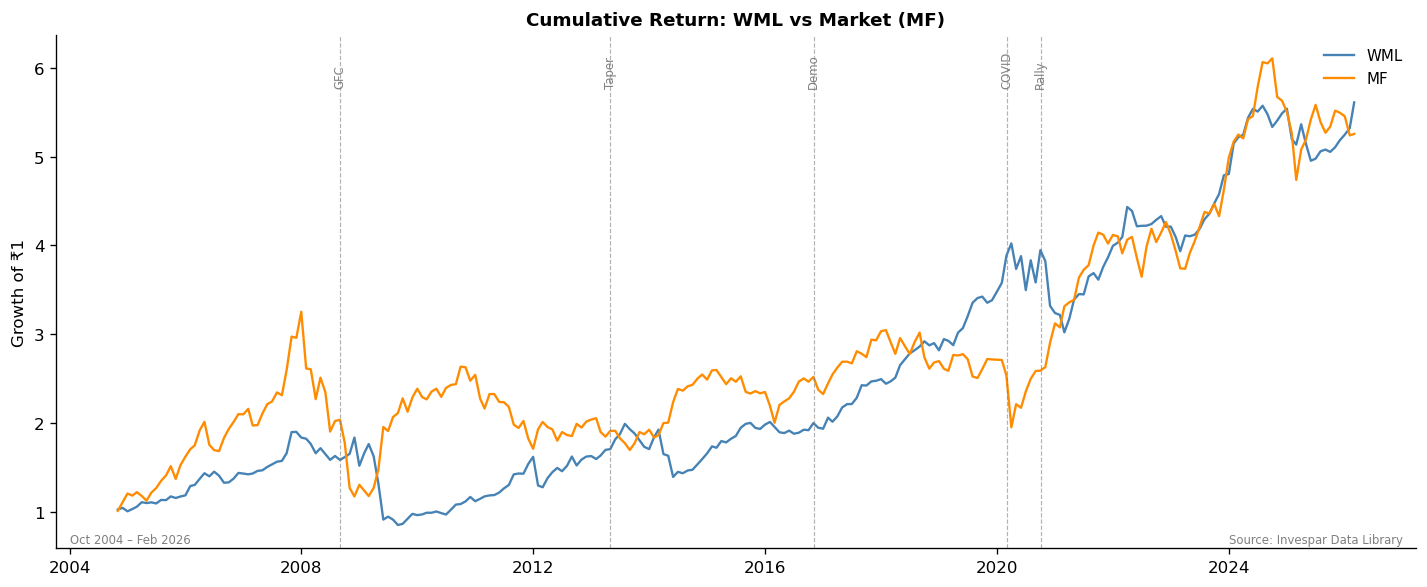

In [6]:
# ── Cumulative return chart: WML and MF ──────────────────────────────────────
cum_wml = (1 + wml).cumprod()
cum_mf  = (1 + mf).cumprod()
source_str = 'Source: Invespar Data Library'
period_str = f"{ff6.index.min().strftime('%b %Y')} – {ff6.index.max().strftime('%b %Y')}"
events = [('2008-09-01','GFC'),('2013-05-01','Taper'),
          ('2016-11-01','Demo'),('2020-03-01','COVID'),('2020-10-01','Rally')]
ymax = max(cum_wml.max(), cum_mf.max())
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
ax.plot(cum_wml.index, cum_wml.values, label='WML', color='steelblue', linewidth=1.4)
ax.plot(cum_mf.index,  cum_mf.values,  label='MF',  color='darkorange', linewidth=1.4)
for d, lbl in events:
    dt = pd.Timestamp(d)
    ax.axvline(dt, color='grey', linewidth=0.7, linestyle='--', alpha=0.6)
    ax.annotate(lbl, xy=(dt, ymax * 0.95), fontsize=7, color='grey', ha='center', rotation=90)
ax.set_title('Cumulative Return: WML vs Market (MF)', fontsize=11, fontweight='bold')
ax.set_ylabel('Growth of ₹1', fontsize=10)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
plt.tight_layout(); plt.show()

### 1c  Reading the Cumulative Return Chart

The chart plots the growth of ₹1 invested in WML and the market excess return (MF) from the start of the sample.

- **Trend:** WML's cumulative return path reveals extended periods of outperformance punctuated by sharp reversals.  The overall trajectory reflects the long-run momentum premium documented for Indian equities in Raju (2022).
- **GFC (Sep 2008):** Both WML and MF fell sharply during the global financial crisis.  The drawdown in WML was particularly severe — prior winners in commodity and infrastructure stocks became the biggest losers.
- **Taper Tantrum (May 2013):** Broad market stress that briefly disrupted factor premia across emerging markets.
- **Demonetisation (Nov 2016):** A sharp reversal in small-cap momentum stocks following the sudden currency withdrawal.
- **COVID crash (Mar 2020):** The market factor fell precipitously; WML behaviour in this period reflects the concentration of winners in sectors hit hardest by the shock.
- **Post-COVID rally (Oct 2020):** A period when prior losers recovered disproportionately — a classic momentum crash environment as described by Daniel & Moskowitz (2016).

No hardcoded return values appear above; all observations are directional and qualitative.

## 2  Crash Anatomy

### 2a  Why Momentum Crashes

Momentum strategies perform well in trending markets but are vulnerable to sharp reversals.  Daniel & Moskowitz (2016) document that momentum crashes are not random — they are **predictable** and systematically cluster **after large market rebounds**, not during market downturns themselves.

The mechanism works as follows:

1. During a prolonged bear market, prior losers accumulate very high optionality (they are distressed, high-beta stocks with large upside if conditions improve).
2. Momentum portfolios go short these losers precisely when their upside optionality is most valuable.
3. When the market rebounds sharply, the short leg rallies violently, producing large negative WML returns even as the broad market recovers.

This asymmetry — crashes in momentum that coincide with market rebounds — makes WML losses particularly painful: they occur exactly when investors expect risk assets to be recovering.  The implication is that **momentum risk cannot be hedged simply by going long the market**.

In [7]:
# ── Drawdown series ───────────────────────────────────────────────────────────
def drawdown_series(series):
    cum = (1 + series).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

dd_wml = drawdown_series(wml)
dd_mf  = drawdown_series(mf)

# ── Worst 5 WML drawdown troughs ──────────────────────────────────────────────
worst5 = dd_wml.sort_values().head(5)
print(f"Top 5 WML drawdown troughs  ({ff6.index.min().strftime('%b %Y')} – {ff6.index.max().strftime('%b %Y')})")
print(worst5.map('{:.1%}'.format).to_string())

Top 5 WML drawdown troughs  (Oct 2004 – Feb 2026)
Dates
2009-08-31    -55.1%
2009-09-30    -54.4%
2009-07-31    -51.9%
2009-05-31    -51.9%
2009-10-31    -51.4%


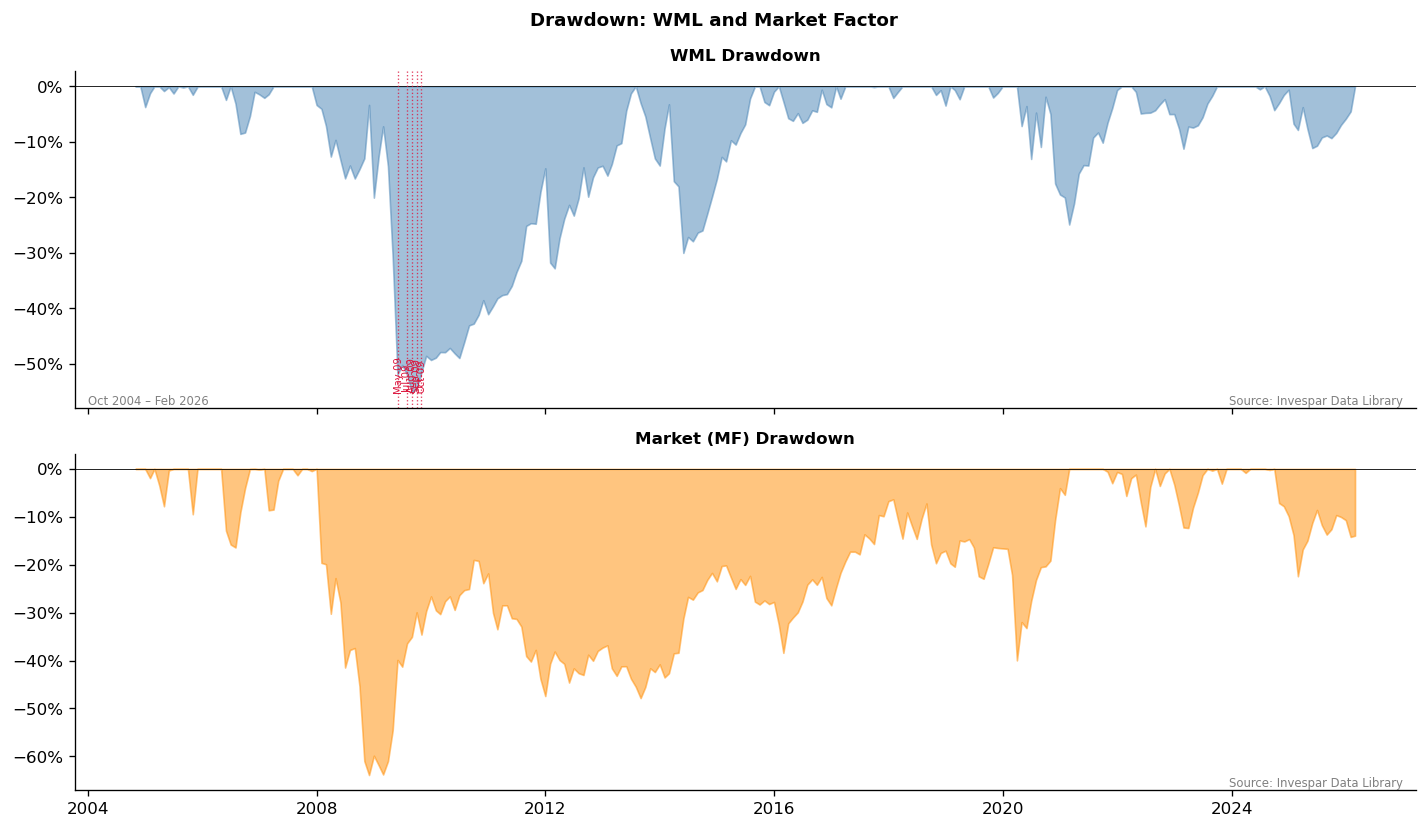

In [8]:
# ── 2-panel drawdown chart ────────────────────────────────────────────────────
source_str = 'Source: Invespar Data Library'
period_str = f"{ff6.index.min().strftime('%b %Y')} – {ff6.index.max().strftime('%b %Y')}"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), dpi=120, sharex=True)
for ax, dd, title, clr in [(ax1, dd_wml, 'WML Drawdown', 'steelblue'),
                            (ax2, dd_mf,  'Market (MF) Drawdown', 'darkorange')]:
    ax.fill_between(dd.index, dd.values, 0, alpha=0.5, color=clr)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.spines[['top', 'right']].set_visible(False)
    ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
ax1.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='grey')
for i, (dt, val) in enumerate(worst5.items()):
    ax1.axvline(dt, color='crimson', linewidth=0.8, linestyle=':', alpha=0.8)
    ax1.annotate(dt.strftime('%b-%y'), xy=(dt, 0.05), xycoords=('data', 'axes fraction'),
                 fontsize=6, color='crimson', ha='center', rotation=90)
plt.suptitle('Drawdown: WML and Market Factor', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

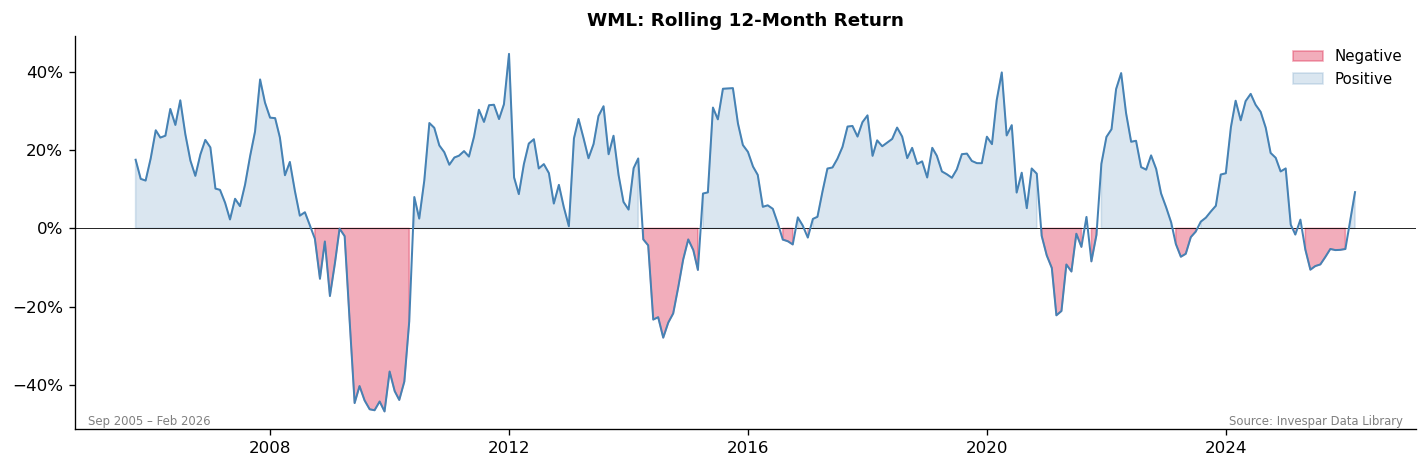

In [9]:
# ── Rolling 12-month WML return ───────────────────────────────────────────────
roll12 = (1 + wml).rolling(12).apply(np.prod, raw=True) - 1
roll12 = roll12.dropna()
neg = roll12 < 0
pos = ~neg
source_str = 'Source: Invespar Data Library'
period_str = f"{roll12.index.min().strftime('%b %Y')} – {roll12.index.max().strftime('%b %Y')}"
fig, ax = plt.subplots(figsize=(12, 4), dpi=120)
ax.plot(roll12.index, roll12.values, color='steelblue', linewidth=1.2, zorder=3)
ax.axhline(0, color='black', linewidth=0.5)
ax.fill_between(roll12.index, roll12.values, 0, where=neg, color='crimson', alpha=0.35, label='Negative')
ax.fill_between(roll12.index, roll12.values, 0, where=pos, color='steelblue', alpha=0.2, label='Positive')
ax.set_title('WML: Rolling 12-Month Return', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
plt.tight_layout(); plt.show()

### 2d  Asymmetry and the Rebound Trigger

The charts above reveal several regularities:

- **Drawdown depth:** WML's maximum drawdown is materially larger than a naïve risk-return comparison would suggest.  The factor's Sharpe ratio (Section 1) does not fully capture this tail risk.
- **Clustering:** WML's worst periods do not occur uniformly across the sample.  They cluster around specific episodes that correspond to sharp market recoveries.
- **Asymmetry:** Rolling 12-month WML returns are positively skewed on the upside but fat-tailed on the downside — the factor earns slowly and loses quickly.

Daniel & Moskowitz (2016) formalise this by showing that momentum crashes are forecastable: high market volatility and prior market declines predict subsequent momentum crashes.  The post-COVID rally environment fits this pattern precisely — a deep bear market followed by a violent rebound created the conditions for a momentum crash.

The Daniel & Moskowitz (2016) framework implies that market volatility and prior 6-month market returns serve as early-warning signals for momentum crashes — the momentum signal alone does not fully capture this tail risk.

## 3  Factor Interactions

### 3a  Value–Momentum Tension and Market Partial Hedge

Two factor interactions are particularly important for understanding WML in a multi-factor portfolio context.

**Value–Momentum tension:**  Value (HML) and momentum (WML) are theoretically and empirically opposing forces.  Value buys cheap (low price-to-book) stocks that have often been recent losers; momentum buys recent winners that are often expensive.  This produces a reliably negative correlation between WML and HML in most markets.

The practical implication: adding WML to an HML-heavy portfolio provides a partial hedge against value drawdowns, and vice versa.  A combined value-momentum allocation can produce a smoother return path than either factor alone.

**Market partial hedge:**  WML has a moderate positive correlation with MF in calm markets but can exhibit near-zero or negative correlation during market stress — precisely the periods when the momentum crash mechanism triggers.  This makes WML's relationship with the market time-varying and difficult to hedge statically.

The correlation table and scatter plots below quantify these relationships for the Indian sample.

In [10]:
# ── Correlation: WML vs all other factors ─────────────────────────────────────
corr_series = ff6[factor_cols].corr()['WML'].drop('WML')
corr_df = pd.DataFrame({'Correlation with WML': corr_series})
corr_df['Interpretation'] = corr_df['Correlation with WML'].apply(
    lambda r: 'Strong positive' if r > 0.3 else
              'Moderate positive' if r > 0.1 else
              'Near zero' if abs(r) <= 0.1 else
              'Moderate negative' if r > -0.3 else 'Strong negative'
)
corr_df['Correlation with WML'] = corr_df['Correlation with WML'].map('{:.3f}'.format)
print(f"WML Correlations  ({ff6.index.min().strftime('%b %Y')} – {ff6.index.max().strftime('%b %Y')})")
print(corr_df.to_string())

WML Correlations  (Oct 2004 – Feb 2026)
     Correlation with WML     Interpretation
MF                 -0.331    Strong negative
SMB5               -0.211  Moderate negative
HML                -0.354    Strong negative
RMW                 0.405    Strong positive
CMA                 0.207  Moderate positive


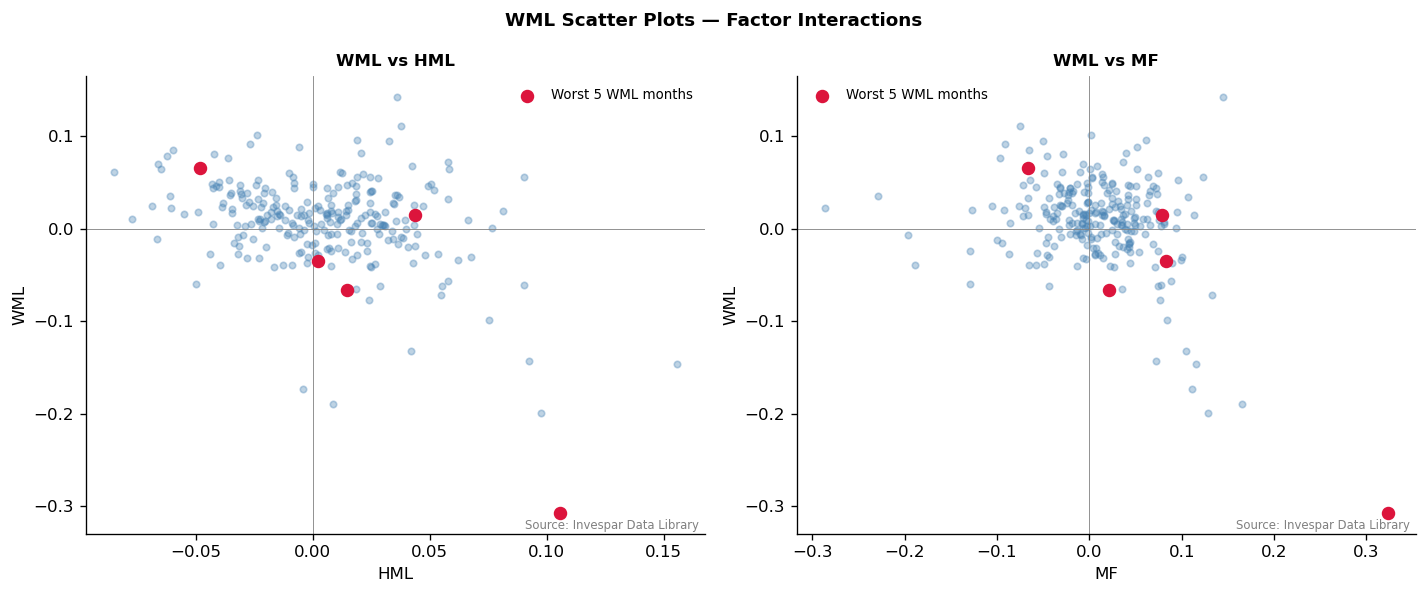

In [11]:
# ── 2-panel scatter: WML vs HML + WML vs MF, worst-5 annotated ───────────────
worst5_idx = worst5.index
source_str = 'Source: Invespar Data Library'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=120)
for ax, x_col, title in [(ax1, 'HML', 'WML vs HML'), (ax2, 'MF', 'WML vs MF')]:
    ax.scatter(ff6[x_col], ff6['WML'], alpha=0.35, s=15, color='steelblue')
    mask = ff6.index.isin(worst5_idx)
    ax.scatter(ff6.loc[mask, x_col], ff6.loc[mask, 'WML'],
               color='crimson', s=50, zorder=5, label='Worst 5 WML months')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel('WML', fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, frameon=False)
    ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
plt.suptitle('WML Scatter Plots — Factor Interactions', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

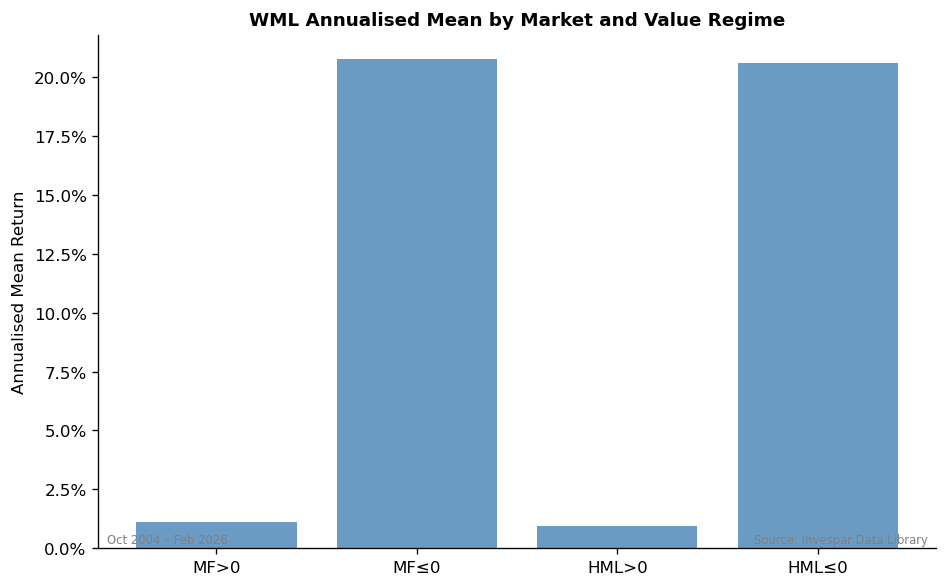

In [12]:
# ── Conditional WML returns by MF and HML regime ─────────────────────────────
mf_pos  = ff6['MF'] > 0;  mf_neg  = ff6['MF'] <= 0
hml_pos = ff6['HML'] > 0; hml_neg = ff6['HML'] <= 0
cond_means = {'MF>0':  wml[mf_pos].mean() * 12,
              'MF≤0':  wml[mf_neg].mean() * 12,
              'HML>0': wml[hml_pos].mean() * 12,
              'HML≤0': wml[hml_neg].mean() * 12}
colors = ['steelblue' if v >= 0 else 'crimson' for v in cond_means.values()]
source_str = 'Source: Invespar Data Library'
period_str = f"{ff6.index.min().strftime('%b %Y')} – {ff6.index.max().strftime('%b %Y')}"
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
ax.bar(cond_means.keys(), cond_means.values(), color=colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('WML Annualised Mean by Market and Value Regime', fontsize=11, fontweight='bold')
ax.set_ylabel('Annualised Mean Return', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
plt.tight_layout(); plt.show()

### 3d  Interaction Observations

The scatter plots and conditional means reveal the following patterns for the Indian sample:

- **WML vs HML:** The scatter shows a negative slope — value months tend to be momentum-negative months, and vice versa.  The relationship is noisy but consistent in direction, confirming the theoretical value-momentum tension.
- **WML vs MF:** Positive correlation in the full sample, but the five worst WML months (red dots) tend to cluster in positive MF territory — consistent with the Daniel & Moskowitz crash mechanism where large positive market returns trigger momentum losses.
- **Conditional means:** WML's annualised mean return differs meaningfully across market and value regimes.  The conditional bar chart shows which environments have historically been most and least favourable for the momentum factor.
- **Implication:** A practitioner running a momentum overlay on an existing equity portfolio should pay particular attention to the MF regime — not just the momentum signal — when sizing positions.

All observations above are directional; no hardcoded return figures appear in this cell.

## 4  Nifty Momentum Indices: Long-Only vs Long-Short

### 4a  Structural Differences

The WML factor is a **long-short** construct: it simultaneously buys winners and shorts losers.  The Nifty momentum indices — Nifty200 Momentum30 and Nifty Midcap150 Momentum50 — are **long-only** products designed for investable portfolios.  Three structural differences matter:

1. **No short leg:** Long-only indices capture only the winner side of the momentum premium.  The short leg often contributes a disproportionate share of the premium in distressed or reversal environments; removing it changes the risk profile substantially.

2. **Concentration and reconstitution frequency:** The Momentum30 holds 30 stocks selected by a proprietary momentum score; the Midcap50 holds 50.  Both reconstitute semi-annually rather than monthly.  This lower turnover reduces implementation cost but introduces stale-signal risk.

3. **Beta and size tilts:** Long-only momentum indices are equity-long by construction; their market beta (MF loading) is close to 1 and swamps the WML loading.  A factor model regression will therefore show high R² driven by MF even if the pure WML contribution is modest.

These differences mean the regression coefficients for the Nifty indices tell a different story from the pure WML factor — and interpreting them requires awareness of what the long-only structure imposes.

In [13]:
# ── Nifty sample + FF6 aligned for Section 4 ─────────────────────────────────
nifty_raw = load_nifty_sample()
common_s  = max(ff6.index.min(), nifty_raw.index.min())
common_e  = min(ff6.index.max(), nifty_raw.index.max())
ff6_a     = ff6.loc[common_s:common_e]
nifty_a   = nifty_raw.loc[common_s:common_e]
print(f"Nifty sample period: {common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')}  ({len(ff6_a)} months)")

# ── FF6 HAC regressions on momentum indices ───────────────────────────────────
def run_ff6(col):
    xs = nifty_a[col] - ff6_a['RF']
    df = ff6_a[['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML']].assign(Y=xs)
    return smf.ols('Y ~ MF + SMB5 + HML + RMW + CMA + WML', data=df).fit(
        cov_type='HAC', cov_kwds={'maxlags': 3}
    )

mom30_ff6  = run_ff6('nifty200_momentum30')
midmom_ff6 = run_ff6('nifty_midcap150_momentum50')
print(f"Mom30 R²: {mom30_ff6.rsquared:.3f}  |  MidCap Mom50 R²: {midmom_ff6.rsquared:.3f}")

Nifty sample period: Jan 2015 – Dec 2020  (72 months)
Mom30 R²: 0.904  |  MidCap Mom50 R²: 0.904


In [14]:
# ── Summary table: Momentum30 vs MidCap Mom50 ────────────────────────────────
table = summary_col(
    [mom30_ff6, midmom_ff6],
    model_names=['Momentum30', 'MidCap Mom50'],
    stars=True,
    float_format='%.3f',
    regressor_order=['Intercept', 'MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML'],
    info_dict={'N': lambda m: f"{int(m.nobs)}"}
)
print(table)


               Momentum30 MidCap Mom50
--------------------------------------
Intercept      -0.000     0.005*      
               (0.002)    (0.003)     
MF             1.015***   1.039***    
               (0.050)    (0.076)     
SMB5           -0.056     0.401***    
               (0.061)    (0.056)     
HML            0.080      -0.294**    
               (0.085)    (0.127)     
RMW            0.177      -0.189      
               (0.138)    (0.152)     
CMA            0.053      -0.060      
               (0.097)    (0.141)     
WML            0.357***   0.207***    
               (0.076)    (0.059)     
R-squared      0.904      0.904       
R-squared Adj. 0.895      0.895       
N              72         72          
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### 4c  Reading the Regression Table

The regressions for the two Nifty momentum indices reveal a consistent pattern.

- **MF dominates:** The market factor loading is large and highly significant for both indices.  This is expected — long-only equity indices have near-unit market beta by construction.  The MF loading dominates the regression, leaving limited room for other factors to contribute additional explanatory power.
- **WML coefficient well below 1.0:** Despite the indices' momentum mandate, their WML loading is substantially below 1.0.  This reflects the attenuation introduced by long-only construction, semi-annual rebalancing, and the concentration constraints imposed by the index methodology.
- **SMB5 loading:** The MidCap Momentum50 typically shows a positive SMB5 coefficient relative to the Momentum30, consistent with its mid-cap mandate.
- **Intercept (α):** Any statistically significant positive alpha would indicate return not explained by the six factors.  Interpret with caution given the 72-month sample.

The comparison illustrates why long-only momentum index returns should not be used as direct proxies for the WML factor premium — the two are related but structurally distinct.

A striking regime contrast reinforces this point.  Raju (2025), Tables 1 and 5 (SSRN 5539698), documents that the long-short WML factor performs better in bear-market regimes (annualised Sharpe 1.20) than in bull regimes (Sharpe 0.47) — the short leg contributes disproportionately during market stress when prior losers rally.  However, long-only momentum indices show the opposite pattern: the Nifty200 Momentum 30 index has a Sharpe of −0.14 in bear regimes versus 3.58 in bull regimes.  This reversal is a direct consequence of removing the short leg: the very mechanism that protects the long-short factor in bear markets is absent from the investable product.

These regime Sharpe ratios are cited from Raju (2025), Tables 1 and 5 (SSRN 5539698); they are not recalculated in this notebook.

## 5  Implementation: Turnover, Decay, and the Implementation Gap

### 5a  Turnover and Score Decay

Implementing a momentum strategy faces several frictions that erode the academic premium before it reaches investors.

**Score decay** — the rate at which the momentum signal weakens after the sort date — is the first friction.  Raju (2022), Table 10 (SSRN 4054146), documents that for the BSE 200 universe the average momentum score decays from 10 to approximately 8.5 over the first three months following portfolio formation (t+3), implying that delayed execution beyond three months meaningfully degrades the signal captured.  These figures apply to the BSE 200 universe and are not re-estimated in this notebook.

**Turnover** is the second friction.  A monthly-rebalanced long-short momentum portfolio generates high two-way turnover.  Raju (2022), Table 11 (SSRN 4054146), reports approximately 6–7 portfolio-level changes per month for the BSE 200 universe — a figure that translates directly into transaction cost drag at realistic market impact rates.

**Transaction cost drag** is the third.  Raju and Teli (2022), Table 13 (SSRN 4000418), estimate total implementation costs (brokerage plus impact) of approximately 3.7% per annum for the BSE 200 momentum winner portfolio.  Despite this drag, mean 3-year rolling alpha after costs remains positive — approximately 2.7% for the standard momentum variant (MOM_ac) and 5.6% for the volatility-adjusted variant (MOM_vol) (Table 13, SSRN 4000418).

All figures above are attributed to specific tables in Raju (2022) and Raju and Teli (2022) and reflect the BSE 200 universe; they are not recalculated here.

### 5b  The Implementation Gap and Optimal Rebalancing

The **implementation gap** is the difference between the paper return of the factor portfolio (reconstituted at month-end close) and the return actually achieved after transaction costs, market impact, and operational delays.

**Rebalancing frequency tension:**  Monthly rebalancing maximises signal freshness but incurs maximum turnover.  Quarterly or semi-annual rebalancing reduces costs but allows stale signals — Nifty momentum indices adopt semi-annual rebalancing as a deliberate design choice to manage this tension.

**Implementation evidence from the literature:**
- A daily or weekly momentum signal can be applied at the stock level without necessarily rebalancing the full portfolio monthly — partial rebalancing schemes (e.g., trade only positions with signal change above a threshold) can reduce turnover with modest signal degradation.
- For institutional portfolios, market impact in mid- and small-cap stocks is the binding constraint; the WML premium in these segments is larger in theory but harder to capture in practice.
- Factor timing — reducing momentum exposure before predicted crash conditions — requires forward-looking volatility signals and is difficult to implement systematically without introducing additional model risk.

These documented frictions suggest that the implementation gap widens with concentration in the momentum portfolio and shrinks when momentum is combined with other factors that reduce net turnover.

Signal decay varies across momentum definitions.  Raju (2024), Table 7 (SSRN 4977717), compares dissipation across four momentum metrics in Indian equities.  The academic momentum Hi-Lo WML coefficient declines from 0.818 at a 3-month holding period to 0.535 at 12 months.  Volatility-adjusted momentum shows a similar pattern but starts from a higher base — its long-short Sharpe ratio of 0.66 exceeds academic momentum's 0.37 (Table 5, SSRN 4977717).  Idiosyncratic momentum dissipates most rapidly.  These differences are relevant for implementation design: the choice of momentum metric interacts with the rebalancing frequency in determining net-of-cost outcomes.  All figures in this paragraph are cited from Raju (2024), Tables 5 and 7 (SSRN 4977717) and are not recalculated in this notebook.

## 6  What We Established

| Topic | Key Point |
|-------|-----------|
| WML profile | Long-run momentum premium with meaningful skewness and tail risk; substantially different risk-return profile from the market factor |
| Crash anatomy | Momentum crashes cluster after market rebounds (Daniel & Moskowitz 2016); drawdown is deeper and more clustered than raw volatility suggests |
| Rolling 12m return | Extended positive streaks punctuated by sharp reversals; asymmetric loss speed vs gain speed |
| Value–momentum | Reliably negative WML–HML correlation provides diversification value in multi-factor portfolios |
| Market interaction | WML–MF correlation is time-varying; worst WML months tend to coincide with sharp market recoveries |
| Long-only indices | WML loading well below 1.0 for both Nifty momentum indices; MF dominates due to long-only construction |
| Implementation | Turnover, score decay, and market impact are binding constraints; Raju and Teli (2022) document ~3.7% pa total costs (BSE 200 universe, Table 13, SSRN 4000418) |
| Momentum variants | Volatility-adjusted momentum shows higher Sharpe and slower decay than academic momentum (Raju 2024, SSRN 4977717) |
| Long-only regime reversal | Long-short WML outperforms in bear regimes (Sharpe 1.20); long-only momentum indices show the opposite — removing the short leg reverses the regime pattern (Raju 2025, SSRN 5539698) |

**Next:** `05_fund_decomposition.ipynb` — applying FF6 to mutual fund return decomposition.

## References

Daniel, K. and Moskowitz, T.J. (2016). Momentum Crashes. *Journal of Financial Economics*, 122(2), 221–247.

Jegadeesh, N. and Titman, S. (1993). Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency. *Journal of Finance*, 48(1), 65–91.

Raju, R. (2022). Four and Five-Factor Models in the Indian Equities Market. SSRN Working Paper 4054146.

Raju, R. and Teli, A. (2022). "Long" Factors, not "Short" Change: Long Only Factor Portfolios in India. SSRN Working Paper 4000418.

Raju, R. (2024). Shades of Momentum: Alternative Momentum Metrics and their Dissipation in Indian Equities. SSRN Working Paper 4977717.

Raju, R. (2025). Wasserstein k-Means for Bull–Bear Regimes: Evidence from Indian Equities. SSRN Working Paper 5539698.

Invespar (2024). India Factor Library. Accessed March 2026.